In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


In [3]:
Names = np.array(["Zero", "Sjoerd", "Liam", "Koen", "Richard", "Tim", "Sam", "Joaquin", "Dorian", "Emma", "Elio", "Danielle"])
Mass = np.array([0, 109.95, 91.05, 86.7, 95.15, 104.40, 104.05, 74.55, 74.55, 64.80, 58.65, 64.40])
Count = np.array([-520334.40, -3446526.00, -2907385.25, -2791163.50, -3006724.24, -3259088.00, -3248268.50, -2474684.25, -2472603.75, -2223376.25, -2058640.75, -2205856.25])

result = np.array([-3432588.00])
result_mass = np.array([110.60])

In [4]:
def linear(x, a, b):
    return a*x + b

pop, cov = curve_fit(linear, Count, Mass)

print("a:", pop[0], "b:", pop[1])

# Smooth x-values for drawing the fitted line
Count_fit = np.linspace(min(Count), max(Count), 100)

a: -3.794351126481836e-05 b: -19.44811336625209


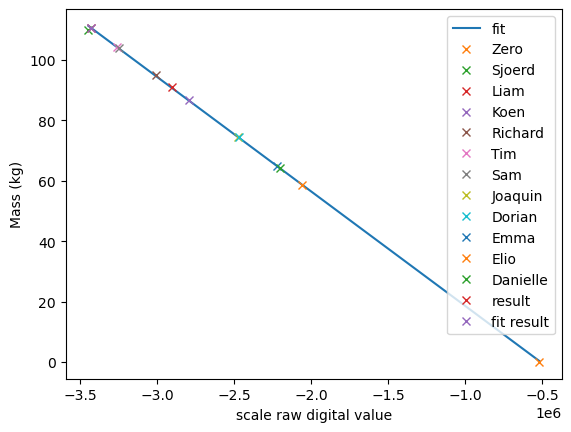

In [11]:
plt.figure()

# Plot fit over entire dataset
plt.plot(Count_fit, linear(Count_fit, *pop), label="fit")

# Plot each datapoint with its own name in the legend
for name, count, mass in zip(Names, Count, Mass):
    plt.plot(count, mass, "x", label=name)

# Plot result and fitted result
plt.plot(result, result_mass, "x", label="result")
plt.plot(result, linear(result, *pop), "x", label="fit result")

plt.xlabel("scale raw digital value")
plt.ylabel("Mass (kg)")
plt.legend()
plt.savefig('calibration.png')
plt.show()